In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/mahmoudshaheen1134
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Citrus Canker
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Dry Leaf
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Curl Virus
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Healthy Leaf
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Anthracnose
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Bacterial Blight
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Sooty Mould
/kaggle/input/datasets/mahmouds

In [2]:
import os

dataset_path = "/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset"

classes = os.listdir(dataset_path)

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    
    if os.path.isdir(class_path):
        print(f"{cls}: {len(os.listdir(class_path))} images")
        

Citrus Canker: 178 images
Dry Leaf: 186 images
Curl Virus: 115 images
Healthy Leaf: 210 images
Anthracnose: 100 images
Bacterial Blight: 105 images
Sooty Mould: 153 images
Spider Mites: 114 images
Deficiency Leaf: 193 images


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-05-30 17:08:24.667645: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780160904.836764      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780160904.887641      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780160905.279079      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780160905.279127      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780160905.279130      22 computation_placer.cc:177] computation placer alr

In [4]:
dataset_path = "/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset"

In [5]:
img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [6]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1086 images belonging to 9 classes.
Found 268 images belonging to 9 classes.


In [7]:
import requests

try:
    r = requests.get("https://www.google.com", timeout=10)
    print("Internet Working")
except:
    print("No Internet")

Internet Working


In [8]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.load_weights(
    "/kaggle/input/datasets/ashishkumar4320/densenet121-imagenet-weights/densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5"
)

print("DenseNet121 weights loaded successfully!")

I0000 00:00:1780160930.204651      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


DenseNet121 weights loaded successfully!


In [9]:
model = Sequential([
    base_model,
    
    GlobalAveragePooling2D(),
    
    Dense(256, activation='relu'),
    Dropout(0.4),
    
    Dense(128, activation='relu'),
    Dropout(0.3),
    
    Dense(9, activation='softmax')
])

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1780160990.842043      82 service.cc:152] XLA service 0x7eefec002160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780160990.842092      82 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780161001.272242      82 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780161100.822919      82 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


34/34 ━━━━━━━━━━━━━━━━━━━━ 322s 5s/step - accuracy: 0.4565 - loss: 1.5948 - val_accuracy: 0.1754 - val_loss: 44.5334 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 691ms/step - accuracy: 0.8566 - loss: 0.4820 - val_accuracy: 0.1194 - val_loss: 134.1597 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 701ms/step - accuracy: 0.9119 - loss: 0.3356 - val_accuracy: 0.4291 - val_loss: 13.9040 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 696ms/step - accuracy: 0.9103 - loss: 0.3281 - val_accuracy: 0.3209 - val_loss: 9.4859 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 691ms/step - accuracy: 0.9194 - loss: 0.2127 - val_accuracy: 0.5299 - val_loss: 2.9163 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 681ms/step - accuracy: 0.9356 - loss: 0.2142 - val_accuracy: 0.3582 - val_loss: 13.5352 - learning_rate: 0.0010
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 681ms/step - accuracy: 0.9191 - loss: 0.2601 - v

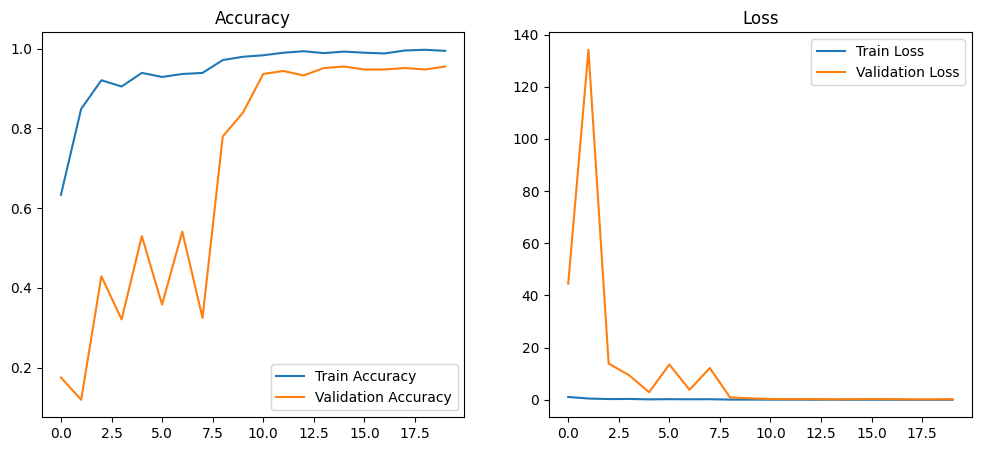

In [13]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [14]:
base_model.trainable = True

In [15]:
for layer in base_model.layers[:-50]:
    layer.trainable = False

In [16]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9977 - loss: 0.0138 - val_accuracy: 0.9552 - val_loss: 0.2118 - learning_rate: 1.0000e-05
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 692ms/step - accuracy: 0.9940 - loss: 0.0342 - val_accuracy: 0.9515 - val_loss: 0.2055 - learning_rate: 1.0000e-05
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 678ms/step - accuracy: 0.9945 - loss: 0.0159 - val_accuracy: 0.9590 - val_loss: 0.2313 - learning_rate: 1.0000e-05
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 681ms/step - accuracy: 0.9973 - loss: 0.0170 - val_accuracy: 0.9552 - val_loss: 0.1737 - learning_rate: 1.0000e-05
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 687ms/step - accuracy: 0.9979 - loss: 0.0149 - val_accuracy: 0.9552 - val_loss: 0.1890 - learning_rate: 1.0000e-05
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 675ms/step - accuracy: 0.9988 - loss: 0.0083 - val_accuracy: 0.9515 - val_loss: 0.1957 - learning_rate: 1.0000e-05
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 687ms/step - accura

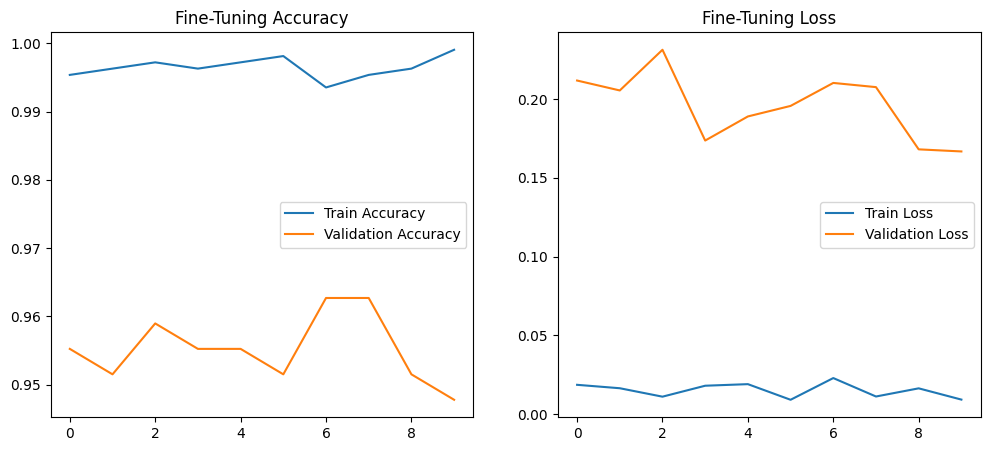

In [18]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(fine_tune_history.history['accuracy'], label='Train Accuracy')
plt.plot(fine_tune_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Fine-Tuning Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(fine_tune_history.history['loss'], label='Train Loss')
plt.plot(fine_tune_history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Fine-Tuning Loss')

plt.show()

In [19]:
print("Final Train Accuracy:", fine_tune_history.history['accuracy'][-1])
print("Final Validation Accuracy:", fine_tune_history.history['val_accuracy'][-1])

print("Final Train Loss:", fine_tune_history.history['loss'][-1])
print("Final Validation Loss:", fine_tune_history.history['val_loss'][-1])

Final Train Accuracy: 0.999079167842865
Final Validation Accuracy: 0.9477611780166626
Final Train Loss: 0.009213794022798538
Final Validation Loss: 0.16675488650798798


9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step


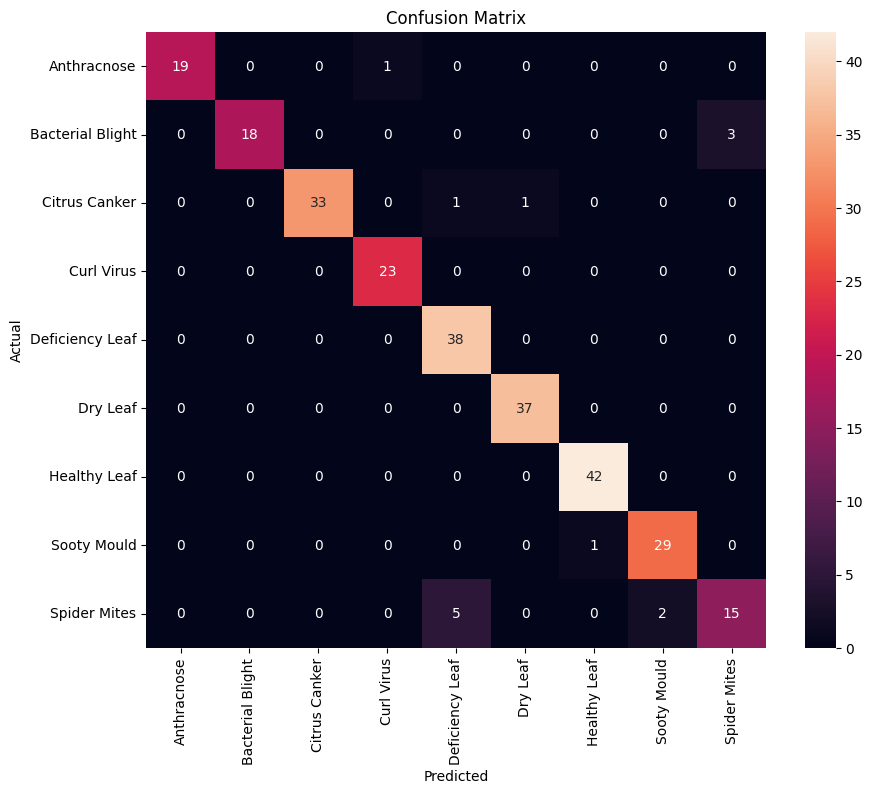

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
predictions = model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

                  precision    recall  f1-score     support
Anthracnose        1.000000  0.950000  0.974359   20.000000
Bacterial Blight   1.000000  0.857143  0.923077   21.000000
Citrus Canker      1.000000  0.942857  0.970588   35.000000
Curl Virus         0.958333  1.000000  0.978723   23.000000
Deficiency Leaf    0.863636  1.000000  0.926829   38.000000
Dry Leaf           0.973684  1.000000  0.986667   37.000000
Healthy Leaf       0.976744  1.000000  0.988235   42.000000
Sooty Mould        0.935484  0.966667  0.950820   30.000000
Spider Mites       0.833333  0.681818  0.750000   22.000000
accuracy           0.947761  0.947761  0.947761    0.947761
macro avg          0.949024  0.933165  0.938811  268.000000
weighted avg       0.948908  0.947761  0.946305  268.000000


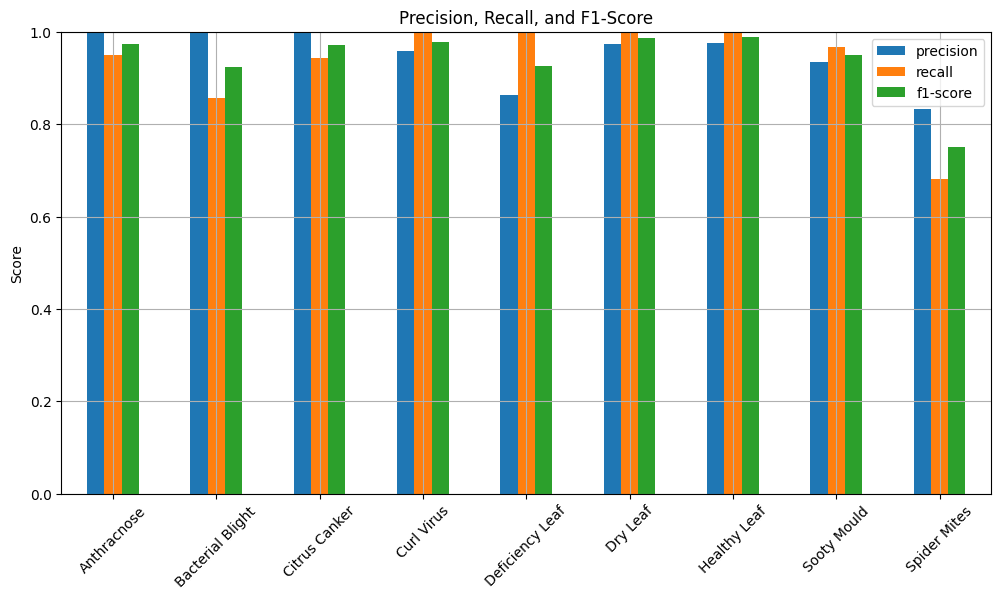

In [22]:
metrics_df = report_df.iloc[:-3, :3]

metrics_df.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Precision, Recall, and F1-Score")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted Disease: Spider Mites


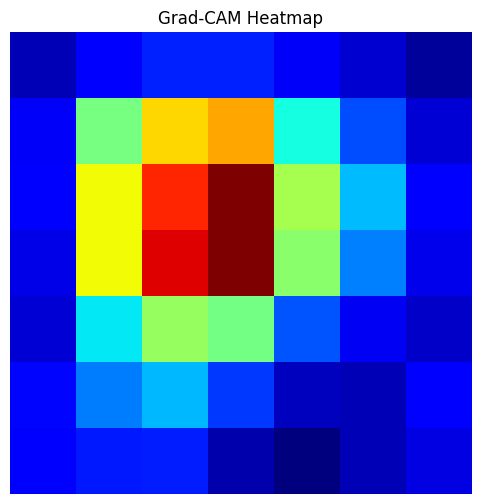

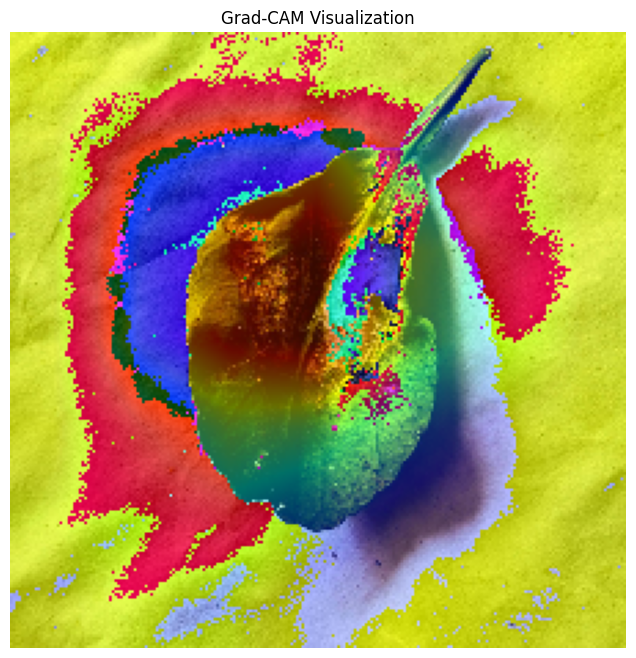

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# =====================================================
# IMAGE PATH
# =====================================================

img_path = "/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Spider Mites/spider_mites00002.JPG"

# =====================================================
# LOAD IMAGE
# =====================================================

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

# =====================================================
# REBUILD FUNCTIONAL MODEL
# =====================================================

inputs = Input(shape=(224,224,3))

base_model = DenseNet121(
    weights=None,
    include_top=False,
    input_tensor=inputs
)

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.3)(x)

outputs = Dense(9, activation='softmax')(x)

functional_model = Model(inputs, outputs)

# =====================================================
# LOAD TRAINED WEIGHTS
# =====================================================

functional_model.set_weights(model.get_weights())

# =====================================================
# CLASS NAMES
# =====================================================

class_names = [
    "Anthracnose",
    "Bacterial Blight",
    "Citrus Canker",
    "Curl Virus",
    "Deficiency Leaf",
    "Dry Leaf",
    "Healthy Leaf",
    "Sooty Mould",
    "Spider Mites"
]

# =====================================================
# PREDICT IMAGE
# =====================================================

predictions = functional_model.predict(img_array)

predicted_class = np.argmax(predictions[0])

print("Predicted Disease:", class_names[predicted_class])

# =====================================================
# LAST CONVOLUTION LAYER
# =====================================================

last_conv_layer = functional_model.get_layer(
    "conv5_block16_concat"
)

# =====================================================
# CREATE GRAD MODEL
# =====================================================

grad_model = Model(
    inputs=functional_model.input,
    outputs=[
        last_conv_layer.output,
        functional_model.output
    ]
)

# =====================================================
# COMPUTE GRAD-CAM
# =====================================================

img_tensor = tf.convert_to_tensor(img_array)

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_tensor)

    predicted_class = tf.argmax(predictions[0])

    class_channel = predictions[:, predicted_class]

# Compute gradients
grads = tape.gradient(class_channel, conv_outputs)

# Mean gradients
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

# Remove batch dimension
conv_outputs = conv_outputs[0]

# Weighted feature maps
heatmap = tf.reduce_sum(
    pooled_grads * conv_outputs,
    axis=-1
)

# Apply ReLU
heatmap = tf.maximum(heatmap, 0)

# Normalize
heatmap = heatmap / tf.reduce_max(heatmap)

heatmap = heatmap.numpy()

# =====================================================
# SHOW HEATMAP
# =====================================================

plt.figure(figsize=(6,6))

plt.imshow(heatmap, cmap='jet')

plt.title("Grad-CAM Heatmap")

plt.axis('off')

plt.show()

# =====================================================
# OVERLAY HEATMAP ON ORIGINAL IMAGE
# =====================================================

img_cv = cv2.imread(img_path)

img_cv = cv2.resize(img_cv, (224,224))

heatmap_resized = cv2.resize(heatmap, (224,224))

heatmap_resized = np.uint8(255 * heatmap_resized)

heatmap_colored = cv2.applyColorMap(
    heatmap_resized,
    cv2.COLORMAP_JET
)

superimposed_img = heatmap_colored * 0.4 + img_cv

# =====================================================
# DISPLAY FINAL GRAD-CAM VISUALIZATION
# =====================================================

plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        np.uint8(superimposed_img),
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Grad-CAM Visualization")

plt.axis('off')

plt.show()

In [24]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dense(
        256,
        activation='relu',
        kernel_regularizer=l2(1e-4)
    ),

    Dropout(0.5),

    Dense(9, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset"

img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1086 images belonging to 9 classes.
Found 268 images belonging to 9 classes.


In [26]:
print(train_data.samples)
print(val_data.samples)

1086
268


In [27]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.3189 - loss: 1.9332 - val_accuracy: 0.1418 - val_loss: 2.5100 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 682ms/step - accuracy: 0.4841 - loss: 1.5090 - val_accuracy: 0.1306 - val_loss: 2.4846 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 691ms/step - accuracy: 0.5499 - loss: 1.3295 - val_accuracy: 0.1455 - val_loss: 2.2996 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 701ms/step - accuracy: 0.5501 - loss: 1.3196 - val_accuracy: 0.2388 - val_loss: 2.2728 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 703ms/step - accuracy: 0.5516 - loss: 1.2622 - val_accuracy: 0.2015 - val_loss: 2.2408 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 708ms/step - accuracy: 0.5843 - loss: 1.2472 - val_accuracy: 0.2052 - val_loss: 2.1472 - learning_rate: 0.0010
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 690ms/step - accuracy: 0.5613 - loss: 1.234

In [28]:
from tensorflow.keras.applications import (
    DenseNet121,
    ResNet50,
    EfficientNetB0,
    MobileNetV2,
    InceptionV3
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.regularizers import l2


def create_model(model_name):

    if model_name == "DenseNet121":
        base_model = DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "ResNet50":
        base_model = ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "EfficientNetB0":
        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "MobileNetV2":
        base_model = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "InceptionV3":
        base_model = InceptionV3(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    base_model.trainable = False

    model = Sequential([
        base_model,

        GlobalAveragePooling2D(),

        BatchNormalization(),

        Dense(
            256,
            activation='relu',
            kernel_regularizer=l2(1e-4)
        ),

        Dropout(0.5),

        Dense(9, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

In [29]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

def train_model(model):

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=20,
        callbacks=[
            early_stop,
            reduce_lr
        ]
    )

    return history

In [30]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

def evaluate_model(model):

    predictions = model.predict(val_data)

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    true_classes = val_data.classes

    class_labels = list(
        val_data.class_indices.keys()
    )

    report = classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()

    accuracy = report_df.loc['accuracy'][0]

    precision = report_df.loc[
        'macro avg'
    ]['precision']

    recall = report_df.loc[
        'macro avg'
    ]['recall']

    f1 = report_df.loc[
        'macro avg'
    ]['f1-score']

    return accuracy, precision, recall, f1

In [31]:
models = [
    "DenseNet121",
    "ResNet50",
    "EfficientNetB0",
    "MobileNetV2",
    "InceptionV3"
]

results = []

for model_name in models:

    print("\nRunning:", model_name)

    model, base_model = create_model(
        model_name
    )

    history = train_model(model)

    accuracy, precision, recall, f1 = \
        evaluate_model(model)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])


Running: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.5400 - loss: 1.4863 - val_accuracy: 0.7015 - val_loss: 0.8836 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 708ms/step - accuracy: 0.9303 - loss: 0.2520 - val_accuracy: 0.8769 - val_loss: 0.5037 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 701ms/step - accuracy: 0.9758 - loss: 0.1481 - val_accuracy: 0.9179 - val_loss: 0.3775 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 701ms/step - accuracy: 0.9741 - loss: 0.1301 - val_accuracy: 0.9515 - val_loss: 0.3098 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 708ms/step - accuracy: 0.9790 - loss: 0.1195 - val_accuracy: 0.9440 - val_loss: 0.2773 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 693ms/step - accuracy: 0.9758 - loss: 0.1049 - val_accuracy: 0.9179 - val_loss: 0.2828 - learning_rate: 0.0010
Epoch 7/20
3

/tmp/ipykernel_22/3076100223.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  accuracy = report_df.loc['accuracy'][0]


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.3010 - loss: 1.9557 - val_accuracy: 0.1455 - val_loss: 2.5156 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 706ms/step - accuracy: 0.4776 - loss: 1.5401 - val_accuracy: 0.1418 - val_loss: 2.4097 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 707ms/step - accuracy: 0.5125 - loss: 1.3896 - val_accuracy: 0.2724 - val_loss: 2.3088 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 685ms/step - accuracy: 0.5701 - loss: 1.2716 - val_accuracy: 0.1866 - val_loss: 2.3396 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 692ms/step - accuracy: 0.5567 - loss: 1.2872 - val_accuracy: 0.1679 - val_loss: 2.3497 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 754ms/step - accuracy: 0.5634 - loss: 1.3007 - val_accuracy: 0.2463 - val_loss: 2.0735 - learning_rate: 0.0010
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 692ms/step - accuracy: 0.5847 - loss: 1.186

/tmp/ipykernel_22/3076100223.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  accuracy = report_df.loc['accuracy'][0]


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.1044 - loss: 2.7811 - val_accuracy: 0.1567 - val_loss: 2.2308 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 700ms/step - accuracy: 0.1046 - loss: 2.8069 - val_accuracy: 0.1306 - val_loss: 2.2201 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 695ms/step - accuracy: 0.1037 - loss: 2.6892 - val_accuracy: 0.1567 - val_loss: 2.2150 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 685ms/step - accuracy: 0.1518 - loss: 2.6162 - val_accuracy: 0.1306 - val_loss: 2.2275 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 688ms/step - accuracy: 0.1487 - loss: 2.5922 - val_accuracy: 0.1306 - val_loss: 2.2218 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 689ms/step - accuracy: 0.1762 - loss: 2.4058 - val_accuracy: 0.1306 - val_loss: 2.2258 - learning_rate: 0.0010
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_22/3076100223.py:29: FutureWarning

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5048 - loss: 1.7687 - val_accuracy: 0.7500 - val_loss: 0.7702 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 701ms/step - accuracy: 0.9164 - loss: 0.3214 - val_accuracy: 0.8545 - val_loss: 0.5292 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 685ms/step - accuracy: 0.9208 - loss: 0.2331 - val_accuracy: 0.8619 - val_loss: 0.5177 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 693ms/step - accuracy: 0.9441 - loss: 0.2071 - val_accuracy: 0.8955 - val_loss: 0.4636 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 686ms/step - accuracy: 0.9652 - loss: 0.1495 - val_accuracy: 0.9030 - val_loss: 0.4470 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 694ms/step - accuracy: 0.9760 - loss: 0.1228 - val_accuracy: 0.8881 - val_loss: 0.4035 - learning_rate: 0.0010
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━

/tmp/ipykernel_22/3076100223.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  accuracy = report_df.loc['accuracy'][0]


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.5171 - loss: 1.7429 - val_accuracy: 0.5485 - val_loss: 1.4064 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 695ms/step - accuracy: 0.8583 - loss: 0.5288 - val_accuracy: 0.7425 - val_loss: 0.7834 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 690ms/step - accuracy: 0.9280 - loss: 0.2859 - val_accuracy: 0.8321 - val_loss: 0.5371 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 696ms/step - accuracy: 0.9233 - loss: 0.2887 - val_accuracy: 0.8731 - val_loss: 0.5327 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 690ms/step - accuracy: 0.9295 - loss: 0.2649 - val_accuracy: 0.8507 - val_loss: 0.4876 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 693ms/step - accuracy: 0.9170 - loss: 0.2834 - val_accuracy: 0.8321 - val_loss: 0.5093 - learning_rate: 0.0010
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━

/tmp/ipykernel_22/3076100223.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  accuracy = report_df.loc['accuracy'][0]


In [32]:
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,DenseNet121,0.944030,0.939881,0.927585,0.931314
1,ResNet50,0.511194,0.495163,0.468201,0.469734
2,EfficientNetB0,0.156716,0.017413,0.111111,0.030108
3,MobileNetV2,0.888060,0.885281,0.866831,0.871032
4,InceptionV3,0.869403,0.856107,0.843206,0.847080


In [33]:
comparison_df.to_csv(
    "Benchmark_Results.csv",
    index=False
)

print(comparison_df)

            Model  Accuracy  Precision    Recall  F1 Score
0     DenseNet121  0.944030   0.939881  0.927585  0.931314
1        ResNet50  0.511194   0.495163  0.468201  0.469734
2  EfficientNetB0  0.156716   0.017413  0.111111  0.030108
3     MobileNetV2  0.888060   0.885281  0.866831  0.871032
4     InceptionV3  0.869403   0.856107  0.843206  0.847080


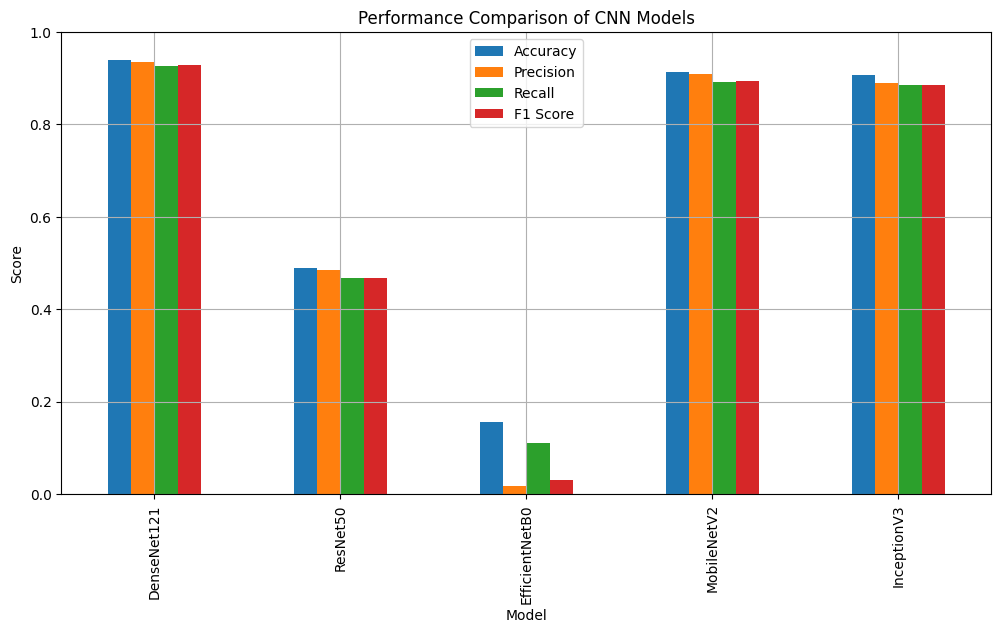

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': ['DenseNet121','ResNet50','EfficientNetB0','MobileNetV2','InceptionV3'],
    'Accuracy': [0.940299,0.488806,0.156716,0.914179,0.906716],
    'Precision': [0.934274,0.484831,0.017413,0.909913,0.889719],
    'Recall': [0.927345,0.467539,0.111111,0.891943,0.885546],
    'F1 Score': [0.928860,0.467969,0.030108,0.894860,0.884772]
})

results.set_index('Model').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Performance Comparison of CNN Models')
plt.ylabel('Score')
plt.ylim(0,1)
plt.grid(True)
plt.legend(loc='best')

plt.show()

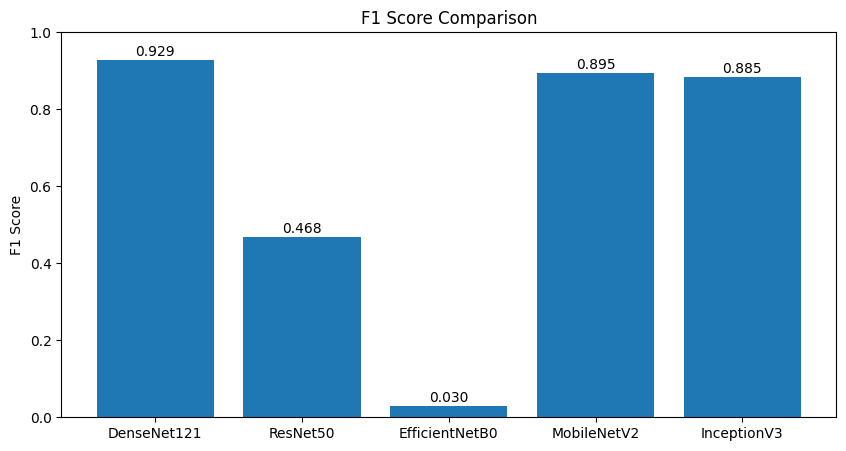

In [35]:
plt.figure(figsize=(10,5))

plt.bar(
    results['Model'],
    results['F1 Score']
)

plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(0,1)

for i,v in enumerate(results['F1 Score']):
    plt.text(i,v+0.01,f"{v:.3f}",ha='center')

plt.show()

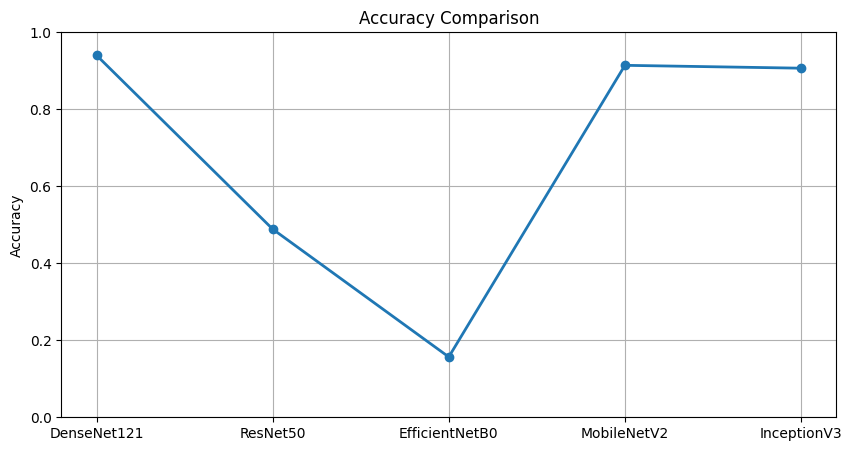

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    results['Model'],
    results['Accuracy'],
    marker='o',
    linewidth=2
)

plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.grid(True)

plt.show()

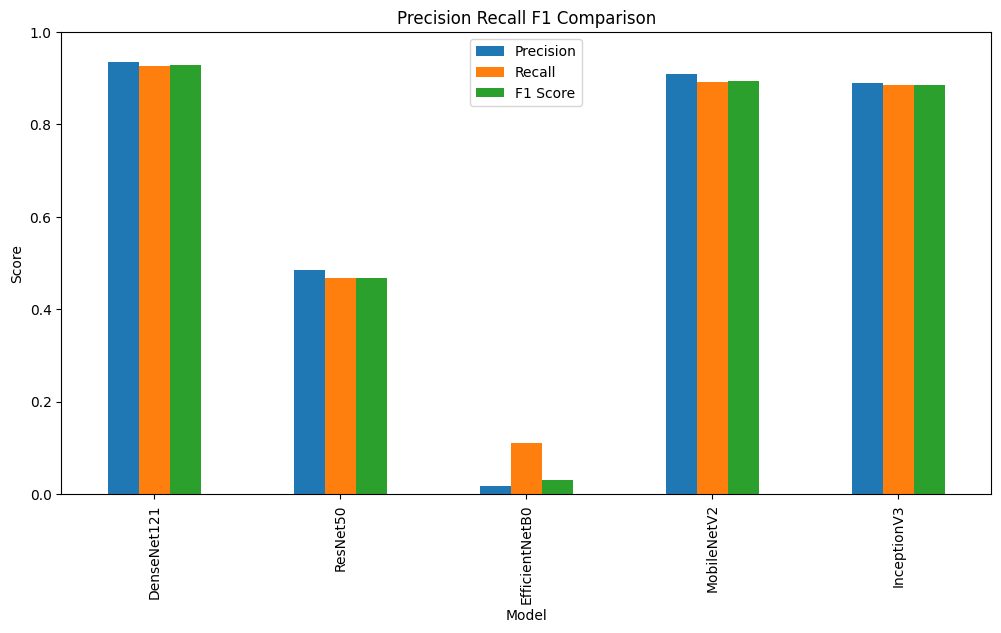

In [37]:
metrics = ['Precision','Recall','F1 Score']

results.set_index('Model')[metrics].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Precision Recall F1 Comparison')
plt.ylabel('Score')
plt.ylim(0,1)

plt.show()

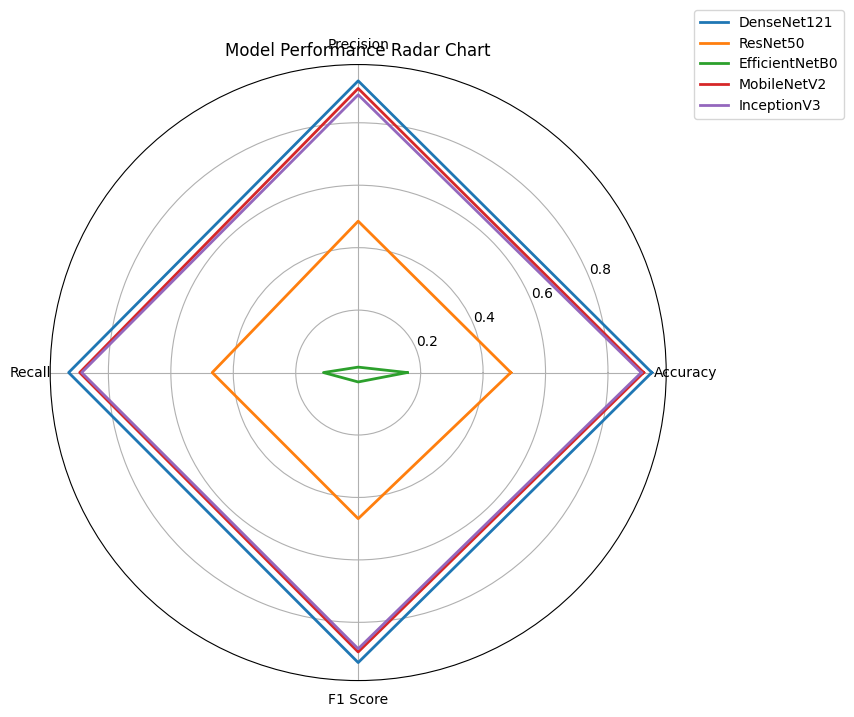

In [38]:
import numpy as np

categories = ['Accuracy','Precision','Recall','F1 Score']

N = len(categories)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for _, row in results.iterrows():

    values = [
        row['Accuracy'],
        row['Precision'],
        row['Recall'],
        row['F1 Score']
    ]

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row['Model']
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.legend(
    bbox_to_anchor=(1.3,1.1)
)

plt.title("Model Performance Radar Chart")

plt.show()

In [39]:
if model_name == "DenseNet121":
    preprocess_input = tf.keras.applications.densenet.preprocess_input

elif model_name == "ResNet50":
    preprocess_input = tf.keras.applications.resnet50.preprocess_input

elif model_name == "EfficientNetB0":
    preprocess_input = tf.keras.applications.efficientnet.preprocess_input

elif model_name == "MobileNetV2":
    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

elif model_name == "InceptionV3":
    preprocess_input = tf.keras.applications.inception_v3.preprocess_input

In [40]:
import tensorflow as tf

In [41]:
preprocess_input = tf.keras.applications.densenet.preprocess_input

In [42]:
def create_model(model_name):

    if model_name == "DenseNet121":
        preprocess_input = tf.keras.applications.densenet.preprocess_input
        base_model = tf.keras.applications.DenseNet121(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "ResNet50":
        preprocess_input = tf.keras.applications.resnet50.preprocess_input
        base_model = tf.keras.applications.ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "EfficientNetB0":
        preprocess_input = tf.keras.applications.efficientnet.preprocess_input
        base_model = tf.keras.applications.EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "MobileNetV2":
        preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "InceptionV3":
        preprocess_input = tf.keras.applications.inception_v3.preprocess_input
        base_model = tf.keras.applications.InceptionV3(
            weights='imagenet',
            include_top=False,
            input_shape=(299,299,3)
        )

    return base_model, preprocess_input

In [43]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import (
    DenseNet121,
    ResNet50,
    EfficientNetB0,
    MobileNetV2,
    InceptionV3
)

models_list = [
    "DenseNet121",
    "ResNet50",
    "EfficientNetB0",
    "MobileNetV2",
    "InceptionV3"
]

results = []

In [44]:
def create_model(model_name, num_classes):

    if model_name == "DenseNet121":

        preprocess = tf.keras.applications.densenet.preprocess_input

        base_model = DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "ResNet50":

        preprocess = tf.keras.applications.resnet50.preprocess_input

        base_model = ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "EfficientNetB0":

        preprocess = tf.keras.applications.efficientnet.preprocess_input

        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "MobileNetV2":

        preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

        base_model = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "InceptionV3":

        preprocess = tf.keras.applications.inception_v3.preprocess_input

        base_model = InceptionV3(
            weights="imagenet",
            include_top=False,
            input_shape=(299,299,3)
        )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=base_model.input_shape[1:])

    x = layers.Lambda(preprocess)(inputs)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [45]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/mahmoudshaheen1134
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Citrus Canker
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Dry Leaf
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Curl Virus
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Healthy Leaf
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Anthracnose
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Bacterial Blight
/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset/Sooty Mould
/kaggle/input/datasets/mahmouds

In [46]:
import tensorflow as tf

DATASET_PATH = "/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 1354 files belonging to 9 classes.
Using 1084 files for training.
Found 1354 files belonging to 9 classes.
Using 270 files for validation.
Classes: ['Anthracnose', 'Bacterial Blight', 'Citrus Canker', 'Curl Virus', 'Deficiency Leaf', 'Dry Leaf', 'Healthy Leaf', 'Sooty Mould', 'Spider Mites']
Number of classes: 9


In [47]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [48]:
num_classes = len(class_names)

print(num_classes)

9


Start Again 

In [49]:
import tensorflow as tf
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras import layers
from tensorflow.keras.models import Model

In [50]:
DATASET_PATH = "/kaggle/input/datasets/mahmoudshaheen1134/lemon-leaf-disease-dataset-lldd/Original Dataset"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)
print("Classes:", num_classes)

Found 1354 files belonging to 9 classes.
Using 1084 files for training.
Found 1354 files belonging to 9 classes.
Using 270 files for validation.
['Anthracnose', 'Bacterial Blight', 'Citrus Canker', 'Curl Virus', 'Deficiency Leaf', 'Dry Leaf', 'Healthy Leaf', 'Sooty Mould', 'Spider Mites']
Classes: 9


In [51]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [52]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [53]:
def create_model(model_name):

    if model_name == "DenseNet121":

        preprocess = tf.keras.applications.densenet.preprocess_input

        base_model = tf.keras.applications.DenseNet121(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "ResNet50":

        preprocess = tf.keras.applications.resnet50.preprocess_input

        base_model = tf.keras.applications.ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "EfficientNetB0":

        preprocess = tf.keras.applications.efficientnet.preprocess_input

        base_model = tf.keras.applications.EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "MobileNetV2":

        preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "InceptionV3":

        preprocess = tf.keras.applications.inception_v3.preprocess_input

        base_model = tf.keras.applications.InceptionV3(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224,224,3))

    x = data_augmentation(inputs)

    x = layers.Lambda(preprocess)(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.5)(x)

    x = layers.Dense(
        256,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [54]:
def evaluate_model(model):

    y_true = []
    y_pred = []

    for images, labels in val_ds:

        predictions = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            np.argmax(labels, axis=1)
        )

        y_pred.extend(
            np.argmax(predictions, axis=1)
        )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='macro'
    )

    return accuracy, precision, recall, f1

In [55]:
models = [
    "DenseNet121",
    "ResNet50",
    "EfficientNetB0",
    "MobileNetV2",
    "InceptionV3"
]

results = []

for model_name in models:

    print("\nTraining:", model_name)

    model = create_model(model_name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=1
    )

    accuracy, precision, recall, f1 = evaluate_model(model)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])


Training: DenseNet121
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 340ms/step - accuracy: 0.1670 - loss: 2.6096 - val_accuracy: 0.3074 - val_loss: 1.9060
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.2554 - loss: 2.1240 - val_accuracy: 0.5481 - val_loss: 1.4749
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.4049 - loss: 1.6995 - val_accuracy: 0.7111 - val_loss: 1.1657
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.5191 - loss: 1.4763 - val_accuracy: 0.7852 - val_loss: 0.9429
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.5846 - loss: 1.2846 - val_accuracy: 0.8593 - val_loss: 0.7666
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.6851 - loss: 1.0716 - val_accuracy: 0.8593 - val_loss: 0.6594
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.6990 - loss: 0.9646 - val_accuracy: 0.8926 - val_loss: 0.5609
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.7129 - loss: 0

E0000 00:00:1780164668.326025      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_12_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step - accuracy: 0.2228 - loss: 2.0946 - val_accuracy: 0.5852 - val_loss: 1.5470
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.5914 - loss: 1.4871 - val_accuracy: 0.7556 - val_loss: 1.1144
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.7187 - loss: 1.1320 - val_accuracy: 0.8370 - val_loss: 0.8423
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.7886 - loss: 0.8821 - val_accuracy: 0.8481 - val_loss: 0.6703
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.8263 - loss: 0.7179 - val_accuracy: 0.8630 - val_loss: 0.5396
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.8691 - loss: 0.5896 - val_accuracy: 0.8593 - val_loss: 0.4815
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.8524 - loss: 0.5302 - val_accuracy: 0.8778 - val_loss: 0.4137
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.8671 - loss: 0.5115 - val_accuracy: 0.8852 - val

In [56]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

results_df.to_csv(
    "benchmark_results.csv",
    index=False
)

            Model  Accuracy  Precision    Recall  F1 Score
1        ResNet50  0.977778   0.976528  0.977170  0.976469
2  EfficientNetB0  0.959259   0.951140  0.963192  0.954727
3     MobileNetV2  0.955556   0.949977  0.950554  0.949724
0     DenseNet121  0.951852   0.947793  0.948728  0.947670
4     InceptionV3  0.925926   0.923096  0.922098  0.921904


In [57]:
import os

os.makedirs("saved_models", exist_ok=True)
os.makedirs("graphs", exist_ok=True)
os.makedirs("confusion_matrices", exist_ok=True)

In [58]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):

    # Accuracy
    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.legend([
        'Train Accuracy',
        'Validation Accuracy'
    ])

    plt.savefig(
        f'graphs/{model_name}_accuracy.png'
    )

    plt.show()

    # Loss
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.legend([
        'Train Loss',
        'Validation Loss'
    ])

    plt.savefig(
        f'graphs/{model_name}_loss.png'
    )

    plt.show()

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

def plot_confusion_matrix(
    model,
    val_ds,
    class_names,
    model_name
):

    y_true = []
    y_pred = []

    for images, labels in val_ds:

        preds = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            np.argmax(labels, axis=1)
        )

        y_pred.extend(
            np.argmax(preds, axis=1)
        )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f'{model_name} Confusion Matrix'
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.savefig(
        f'confusion_matrices/{model_name}_cm.png'
    )

    plt.show()

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(
    model,
    val_ds,
    class_names,
    model_name
):

    y_true = []
    y_pred = []

    for images, labels in val_ds:

        preds = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            np.argmax(labels, axis=1)
        )

        y_pred.extend(
            np.argmax(preds, axis=1)
        )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='macro'
    )

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    return (
        accuracy,
        precision,
        recall,
        f1
    )

In [61]:
model.save(
    f"saved_models/{model_name}.keras"
)


Training DenseNet121
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 265ms/step - accuracy: 0.1451 - loss: 2.5550 - val_accuracy: 0.4370 - val_loss: 1.7527
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.3310 - loss: 1.9144 - val_accuracy: 0.6370 - val_loss: 1.3285
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.4381 - loss: 1.5904 - val_accuracy: 0.7296 - val_loss: 1.0497
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.5343 - loss: 1.4032 - val_accuracy: 0.7778 - val_loss: 0.8389
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.6425 - loss: 1.1605 - val_accuracy: 0.8148 - val_loss: 0.7166
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.6483 - loss: 1.0552 - val_accuracy: 0.8704 - val_loss: 0.5961
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.7088 - loss: 0.8996 - val_accuracy: 0.8852 - val_loss: 0.5110
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.7282 - loss: 0.

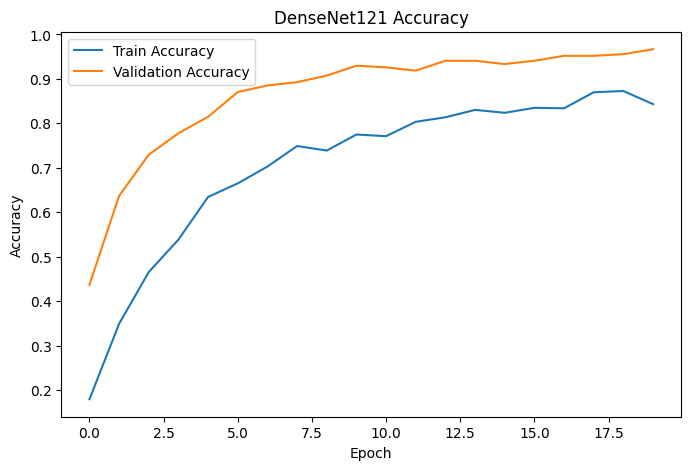

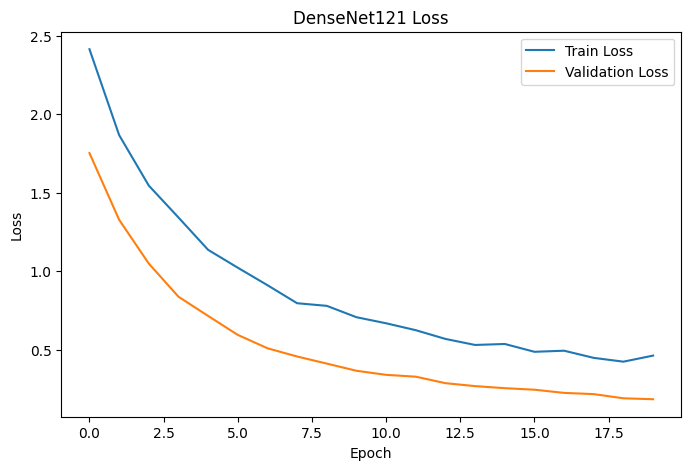

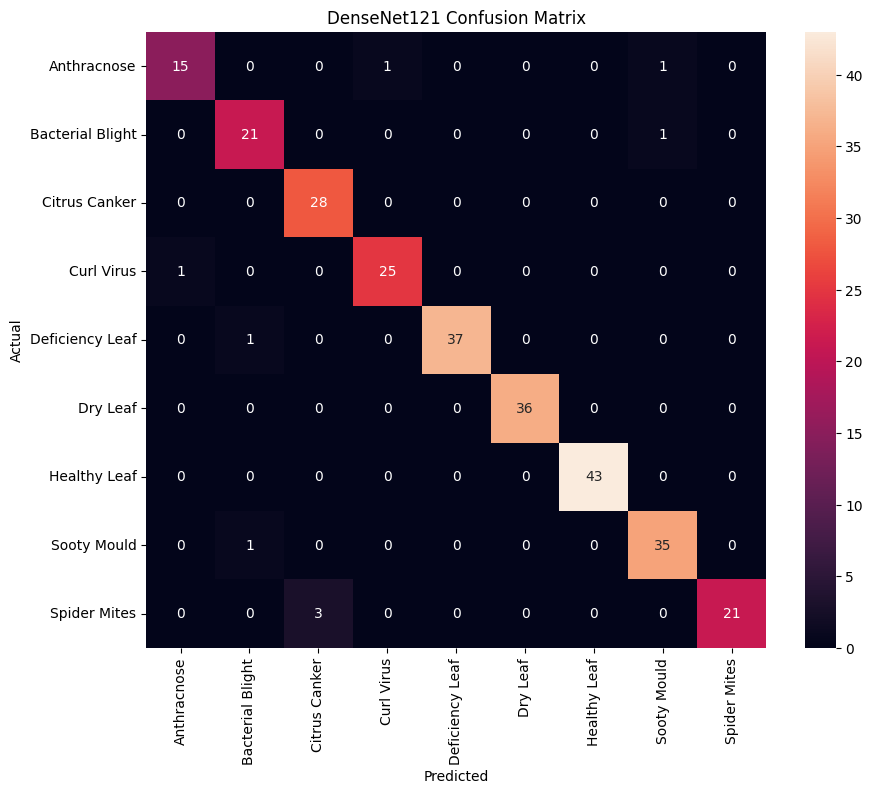

                  precision    recall  f1-score   support

     Anthracnose       0.94      0.88      0.91        17
Bacterial Blight       0.91      0.95      0.93        22
   Citrus Canker       0.90      1.00      0.95        28
      Curl Virus       0.96      0.96      0.96        26
 Deficiency Leaf       1.00      0.97      0.99        38
        Dry Leaf       1.00      1.00      1.00        36
    Healthy Leaf       1.00      1.00      1.00        43
     Sooty Mould       0.95      0.97      0.96        36
    Spider Mites       1.00      0.88      0.93        24

        accuracy                           0.97       270
       macro avg       0.96      0.96      0.96       270
    weighted avg       0.97      0.97      0.97       270


Training ResNet50
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 207ms/step - accuracy: 0.2389 - loss: 2.2964 - val_accuracy: 0.7148 - val_loss: 1.0967
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.5517 - loss: 1.3068 - val_acc

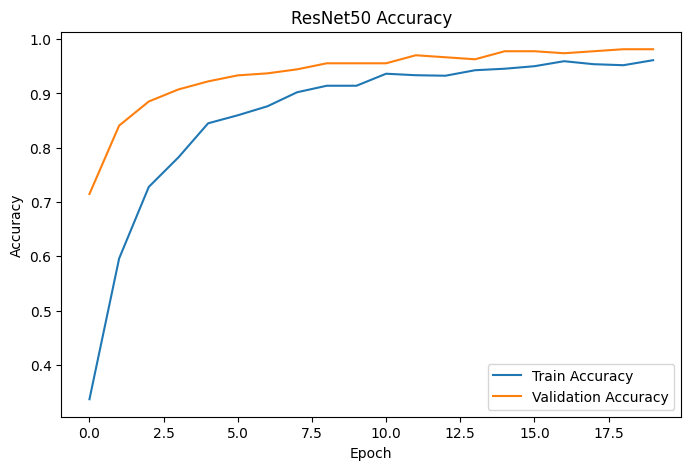

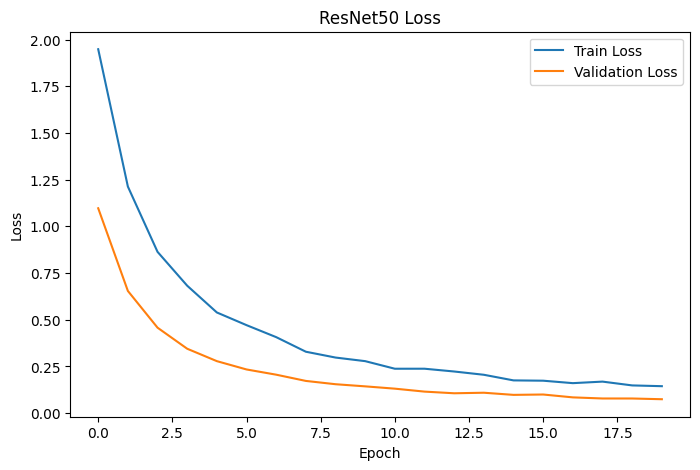

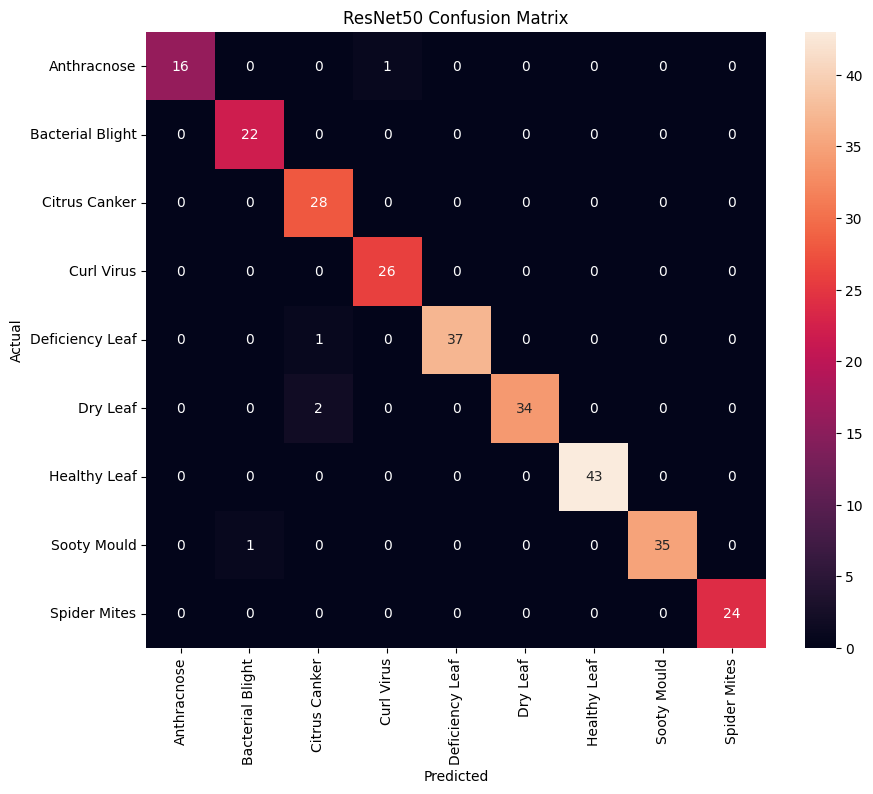

                  precision    recall  f1-score   support

     Anthracnose       1.00      0.94      0.97        17
Bacterial Blight       0.96      1.00      0.98        22
   Citrus Canker       0.90      1.00      0.95        28
      Curl Virus       0.96      1.00      0.98        26
 Deficiency Leaf       1.00      0.97      0.99        38
        Dry Leaf       1.00      0.94      0.97        36
    Healthy Leaf       1.00      1.00      1.00        43
     Sooty Mould       1.00      0.97      0.99        36
    Spider Mites       1.00      1.00      1.00        24

        accuracy                           0.98       270
       macro avg       0.98      0.98      0.98       270
    weighted avg       0.98      0.98      0.98       270


Training EfficientNetB0
Epoch 1/20


E0000 00:00:1780165180.272956      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_17_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.1520 - loss: 2.2888 - val_accuracy: 0.5370 - val_loss: 1.7159
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.5208 - loss: 1.6260 - val_accuracy: 0.7370 - val_loss: 1.2326
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.7084 - loss: 1.1990 - val_accuracy: 0.8296 - val_loss: 0.8963
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.8069 - loss: 0.9221 - val_accuracy: 0.8778 - val_loss: 0.6813
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.8394 - loss: 0.7416 - val_accuracy: 0.8815 - val_loss: 0.5554
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.8518 - loss: 0.6577 - val_accuracy: 0.8926 - val_loss: 0.4731
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.8679 - loss: 0.5309 - val_accuracy: 0.8926 - val_loss: 0.4033
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.8770 - loss: 0.5000 - val_accuracy: 0.9074 - val

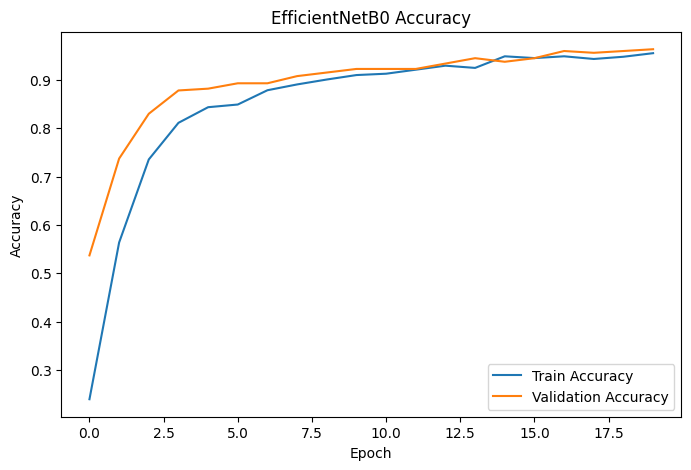

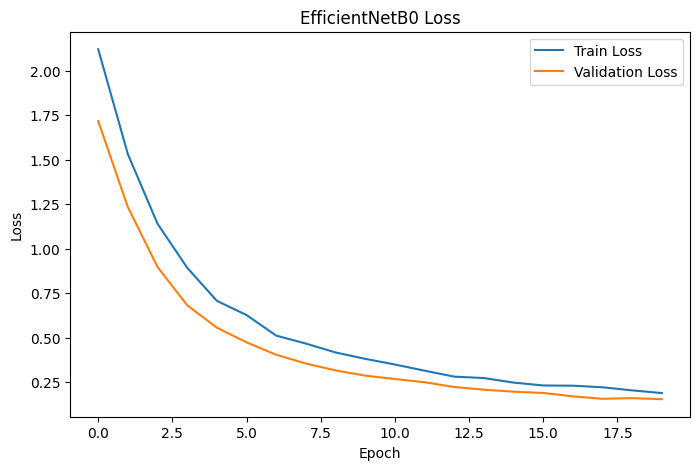

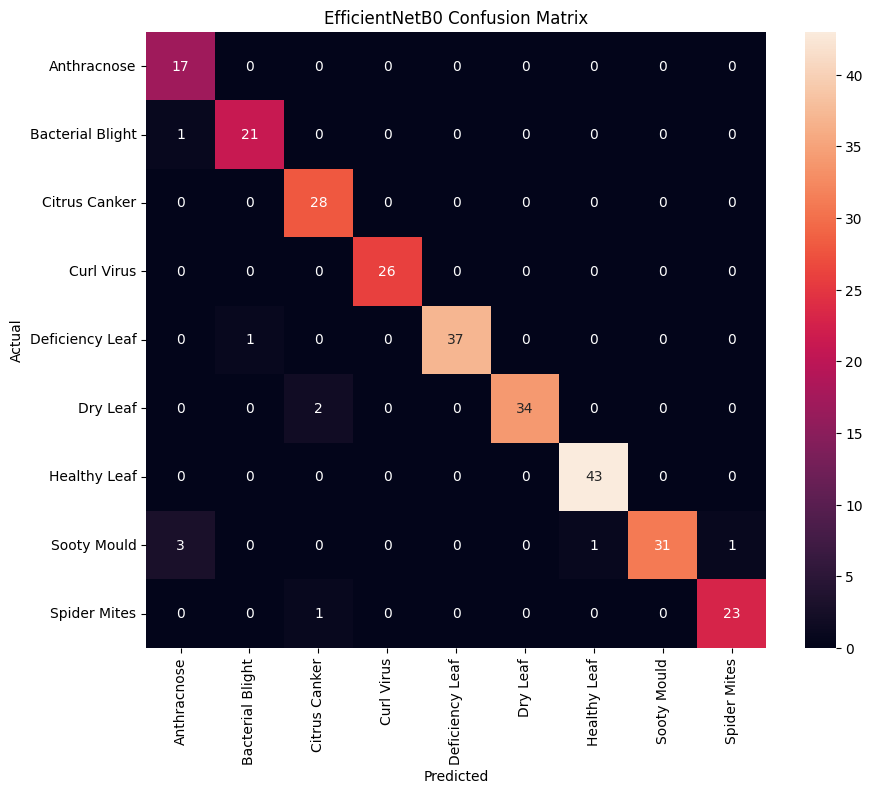

                  precision    recall  f1-score   support

     Anthracnose       0.81      1.00      0.89        17
Bacterial Blight       0.95      0.95      0.95        22
   Citrus Canker       0.90      1.00      0.95        28
      Curl Virus       1.00      1.00      1.00        26
 Deficiency Leaf       1.00      0.97      0.99        38
        Dry Leaf       1.00      0.94      0.97        36
    Healthy Leaf       0.98      1.00      0.99        43
     Sooty Mould       1.00      0.86      0.93        36
    Spider Mites       0.96      0.96      0.96        24

        accuracy                           0.96       270
       macro avg       0.96      0.97      0.96       270
    weighted avg       0.97      0.96      0.96       270


Training MobileNetV2
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.1909 - loss: 2.3488 - val_accuracy: 0.5444 - val_loss: 1.5354
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.4575 - loss: 1.5921 - val_

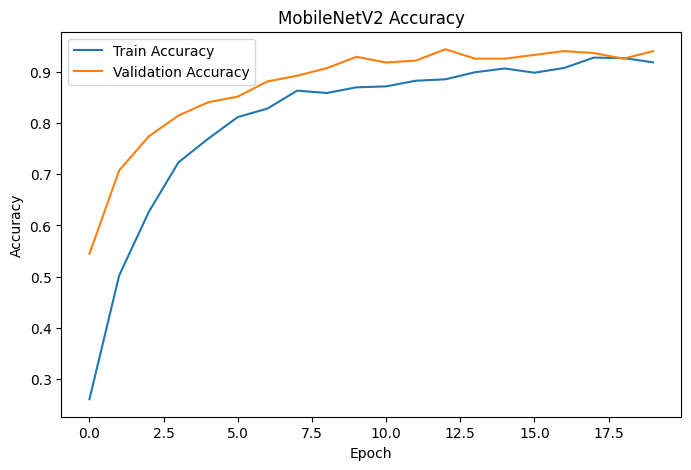

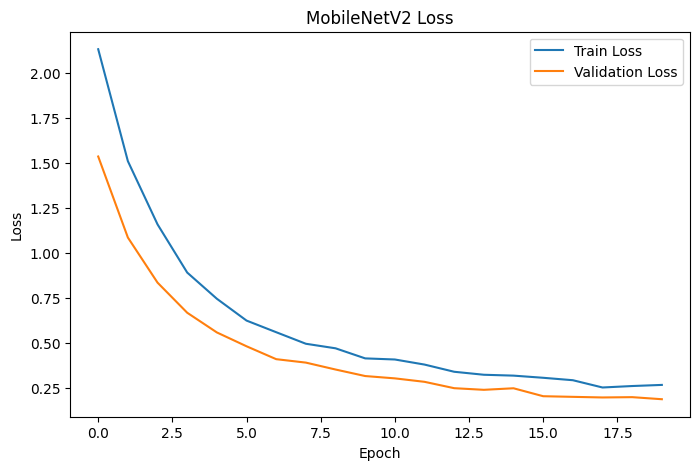

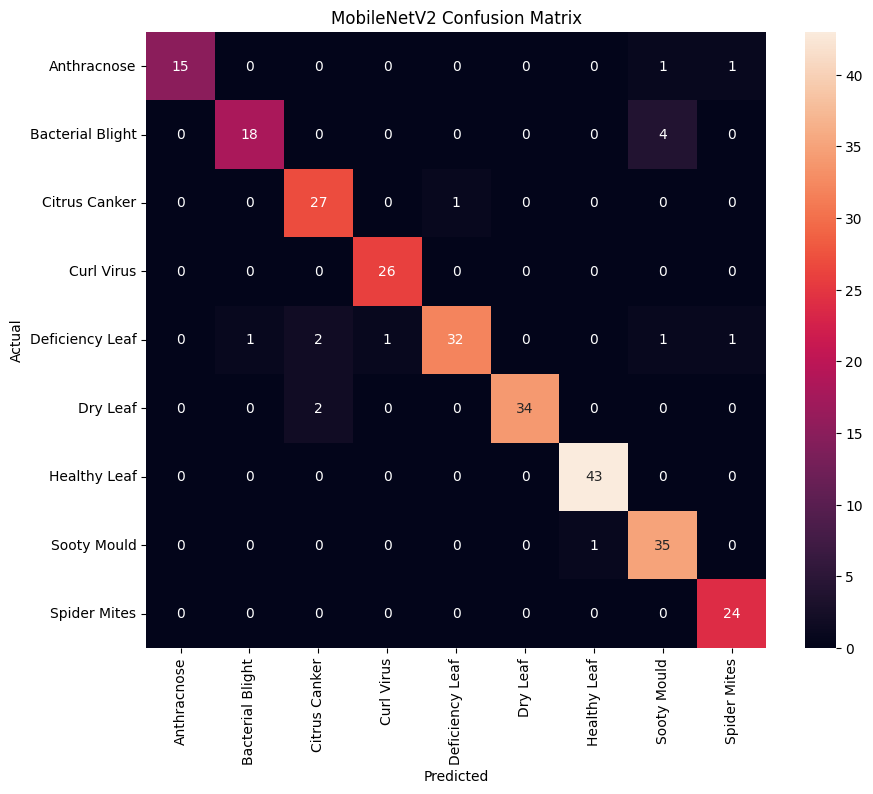

                  precision    recall  f1-score   support

     Anthracnose       1.00      0.88      0.94        17
Bacterial Blight       0.95      0.82      0.88        22
   Citrus Canker       0.87      0.96      0.92        28
      Curl Virus       0.96      1.00      0.98        26
 Deficiency Leaf       0.97      0.84      0.90        38
        Dry Leaf       1.00      0.94      0.97        36
    Healthy Leaf       0.98      1.00      0.99        43
     Sooty Mould       0.85      0.97      0.91        36
    Spider Mites       0.92      1.00      0.96        24

        accuracy                           0.94       270
       macro avg       0.95      0.94      0.94       270
    weighted avg       0.94      0.94      0.94       270


Training InceptionV3
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 205ms/step - accuracy: 0.1869 - loss: 2.3993 - val_accuracy: 0.5778 - val_loss: 1.4607
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.4543 - loss: 1.6157 - val_

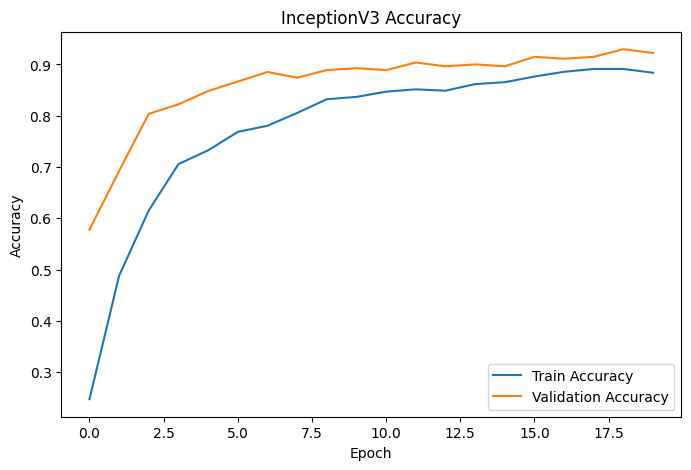

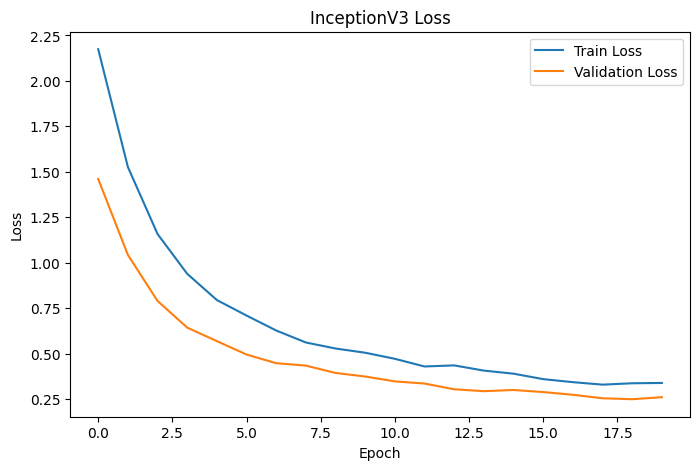

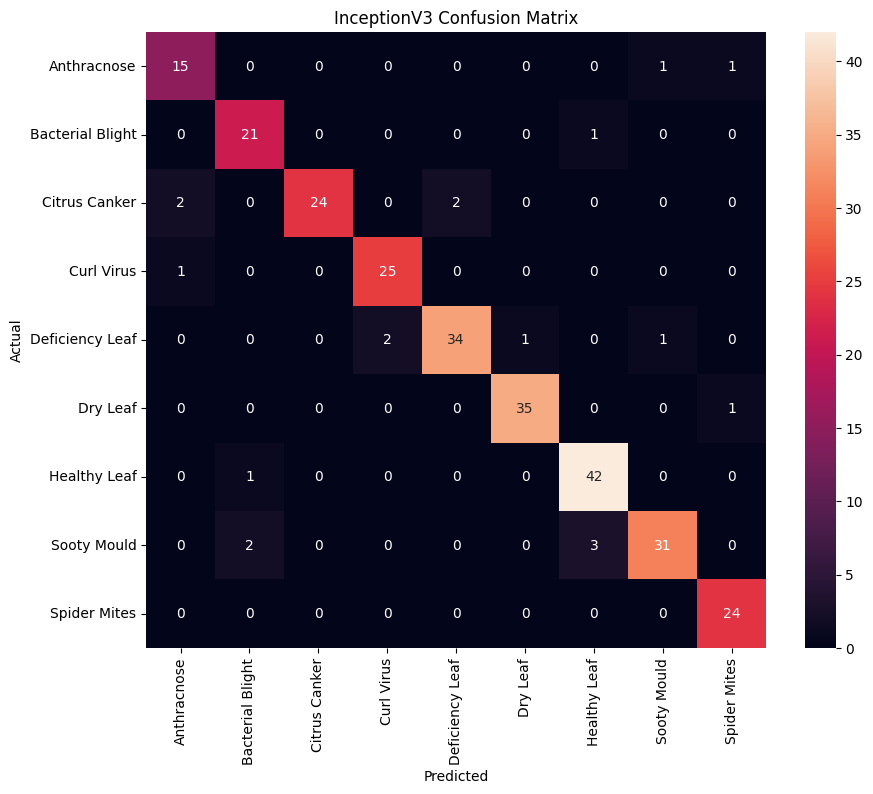

                  precision    recall  f1-score   support

     Anthracnose       0.83      0.88      0.86        17
Bacterial Blight       0.88      0.95      0.91        22
   Citrus Canker       1.00      0.86      0.92        28
      Curl Virus       0.93      0.96      0.94        26
 Deficiency Leaf       0.94      0.89      0.92        38
        Dry Leaf       0.97      0.97      0.97        36
    Healthy Leaf       0.91      0.98      0.94        43
     Sooty Mould       0.94      0.86      0.90        36
    Spider Mites       0.92      1.00      0.96        24

        accuracy                           0.93       270
       macro avg       0.93      0.93      0.93       270
    weighted avg       0.93      0.93      0.93       270



In [62]:
results = []

for model_name in models:

    print("\n====================")
    print("Training", model_name)
    print("====================")

    model = create_model(model_name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                patience=5,
                restore_best_weights=True
            )
        ]
    )

    plot_history(
        history,
        model_name
    )

    plot_confusion_matrix(
        model,
        val_ds,
        class_names,
        model_name
    )

    accuracy, precision, recall, f1 = \
        evaluate_model(
            model,
            val_ds,
            class_names,
            model_name
        )

    model.save(
        f"saved_models/{model_name}.keras"
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [63]:
for model_name in models:

    # Train model
    model = create_model(model_name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20
    )

    # Save model
    model.save(
        f"/kaggle/working/{model_name}.keras"
    )

    print(f"{model_name} saved successfully!")

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - accuracy: 0.1543 - loss: 2.6509 - val_accuracy: 0.3000 - val_loss: 1.9444
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.2979 - loss: 2.0064 - val_accuracy: 0.4852 - val_loss: 1.5404
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.3896 - loss: 1.7743 - val_accuracy: 0.6481 - val_loss: 1.2659
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.4904 - loss: 1.4318 - val_accuracy: 0.7444 - val_loss: 1.0312
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.5702 - loss: 1.3304 - val_accuracy: 0.8074 - val_loss: 0.8412
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.6435 - loss: 1.1086 - val_accuracy: 0.8593 - val_loss: 0.7100
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.6785 - loss: 0.9819 - val_accuracy: 0.8741 - val_loss: 0.6197
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.7177 - loss: 0.8831 - val_accuracy: 0

E0000 00:00:1780165662.604663      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_22_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 189ms/step - accuracy: 0.1826 - loss: 2.1752 - val_accuracy: 0.6074 - val_loss: 1.6437
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.5582 - loss: 1.5606 - val_accuracy: 0.7593 - val_loss: 1.1957
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.7205 - loss: 1.1730 - val_accuracy: 0.8481 - val_loss: 0.9099
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.7841 - loss: 0.9129 - val_accuracy: 0.8704 - val_loss: 0.7235
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.7987 - loss: 0.7805 - val_accuracy: 0.8778 - val_loss: 0.5886
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.8551 - loss: 0.6322 - val_accuracy: 0.8815 - val_loss: 0.5004
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.8630 - loss: 0.5679 - val_accuracy: 0.8926 - val_loss: 0.4295
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.8761 - loss: 0.4655 - val_accuracy: 0.9037 - val

In [64]:
import shutil

shutil.make_archive(
    "/kaggle/working/all_models",
    'zip',
    "/kaggle/working"
)

'/kaggle/working/all_models.zip'